In [140]:
# import necessary libraries for data analysis and visualization
import pandas as pd #For data manipulation and analysis
import numpy as np # For numerical operations
import matplotlib.pyplot as plt # For plotting graph
import seaborn as sns# For advance data visualization
# Import Machine learning Pre-processing Tools
from sklearn.preprocessing import LabelEncoder #For converting categorical data to numerical
from sklearn.cluster import KMeans # For clustering algorithm
from sklearn.preprocessing import StandardScaler # For Feature scaling

In [141]:
# load the Netflix Dataset from CSV file into a DataFrame
df = pd.read_csv("netflix_titles.csv")

In [142]:
# Display the first 5 rows of the dataset
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [143]:
# Display the last 5 rows of the dataset
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [144]:
# Check no. of rows and columns in dataset
df.shape

(8807, 12)

In [145]:
# Display all  columns name in dataset
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [146]:
# Display index information of dataset
df.index

RangeIndex(start=0, stop=8807, step=1)

In [147]:
# Display detailed information about dataset
# Includes column names, Not Null values , datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [148]:
# Generate statistical summary of numerical columns
# Includes mean ,standard deviation , min ,max,etc
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [149]:
# Check total number of missing values in each column
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [150]:
# Fill missing values in specific columns with meaningful placeholders
df["director"].fillna("Unknown",inplace=True)
df["cast"].fillna("Unknown",inplace=True)
df["country"].fillna("Unknown",inplace=True)
df["date_added"].fillna("Not Defined",inplace=True)
df["rating"].fillna("Not Rated",inplace=True)
df["duration"].fillna("Not Defined",inplace=True)
# Display updated dataset
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [151]:
# Remove rows with any remaining missing values
# ( Note: This returns a new dataframe if not assigned)
df.dropna()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [152]:
# Identify duplicate rows in dataset
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
8802    False
8803    False
8804    False
8805    False
8806    False
Length: 8807, dtype: bool

In [153]:
# Remove duplicate rows permanently
df.drop_duplicates(inplace=True)

In [154]:
# Convert 'date_added' column into datetime format
# Errors = 'coerce' convert invalid values into NaT
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [155]:
# Create new column for year when content was added
df["year_added"]=df["date_added"].dt.year
# Create new column for month when content was added
df["month_added"]=df["date_added"].dt.month
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


In [156]:
# Remove unnecessary spaces in country name
df["country"]=df["country"].str.strip()
# Convert titles to lower case for consistency
df["title"]=df["title"].str.lower()
# Remove commas from director names
df["director"]=df["director"].str.replace(",","")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,dick johnson is dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,blood & water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,jailbirds new orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,kota factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


In [157]:
# Create separate dataset for movies and TV shows
movies = df[df['type'] == 'Movie']
tvshows = df[df['type'] == 'TV Show']
# Filter Movies released after 2015
recent_movies = df[df['release_year'] > 2015]
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,dick johnson is dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,blood & water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,jailbirds new orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,kota factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


In [158]:
# Sort dataset by release year(ascending)
df.sort_values(by='release_year')
# Sort dataset by release year(descending)
df.sort_values(by='release_year', ascending=False)
# Sort dataset by date added
df.sort_values(by='date_added')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,dick johnson is dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,blood & water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,jailbirds new orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,kota factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


In [159]:
# Rename column 'listed_in' to 'genre'
df.rename(columns={'listed_in':'genre'}, inplace=True)
# Rename column 'show_id' to 'ID'
df.rename(columns={'show_id':'ID'}, inplace=True)
df.head()

,ID,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,year_added,month_added
0,s1,Movie,dick johnson is dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,blood & water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,jailbirds new orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,kota factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


In [160]:
# Keep only relevant columns for analysis 
df = df[['type','title','director','country','release_year','rating','duration','genre']]
df.head()

,type,title,director,country,release_year,rating,duration,genre
0,Movie,dick johnson is dead,Kirsten Johnson,United States,2020,PG-13,90 min,Documentaries
1,TV Show,blood & water,Unknown,South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,TV Show,ganglands,Julien Leclercq,Unknown,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,TV Show,jailbirds new orleans,Unknown,Unknown,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,TV Show,kota factory,Unknown,India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


In [161]:
# Count number of entries by content type
df.groupby("type").count()
# Count titles by countries
df.groupby("country")["title"].count()
# Count titles by release year
df.groupby("release_year")["title"].count()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: title, Length: 74, dtype: int64

In [162]:
# Create Pivot table showing number of titles by country and type
pd.pivot_table(df,
               values='title',
               index='country',
               columns='type',
               aggfunc='count')
df.head()

,type,title,director,country,release_year,rating,duration,genre
0,Movie,dick johnson is dead,Kirsten Johnson,United States,2020,PG-13,90 min,Documentaries
1,TV Show,blood & water,Unknown,South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,TV Show,ganglands,Julien Leclercq,Unknown,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,TV Show,jailbirds new orleans,Unknown,Unknown,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,TV Show,kota factory,Unknown,India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


In [163]:
# Calculate mean release year
df['release_year'].mean()
# Calculate median release year
df['release_year'].median()
# Calculate standard deviation release year
df['release_year'].std()
# Calculate variance release year
df['release_year'].var()
df.head()

,type,title,director,country,release_year,rating,duration,genre
0,Movie,dick johnson is dead,Kirsten Johnson,United States,2020,PG-13,90 min,Documentaries
1,TV Show,blood & water,Unknown,South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,TV Show,ganglands,Julien Leclercq,Unknown,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,TV Show,jailbirds new orleans,Unknown,Unknown,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,TV Show,kota factory,Unknown,India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


In [164]:
# Count frequency of each content type
df['type'].value_counts()
# Count frequency of each rating
df['rating'].value_counts()
# Count frequency of each country
df['country'].value_counts()
# Count frequency of each genre
df['genre'].value_counts()
df.head()

,type,title,director,country,release_year,rating,duration,genre
0,Movie,dick johnson is dead,Kirsten Johnson,United States,2020,PG-13,90 min,Documentaries
1,TV Show,blood & water,Unknown,South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,TV Show,ganglands,Julien Leclercq,Unknown,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,TV Show,jailbirds new orleans,Unknown,Unknown,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,TV Show,kota factory,Unknown,India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


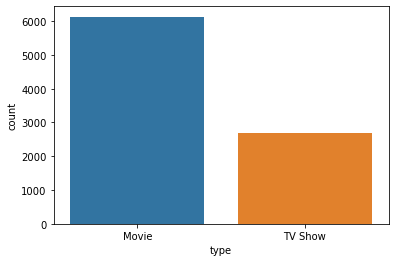

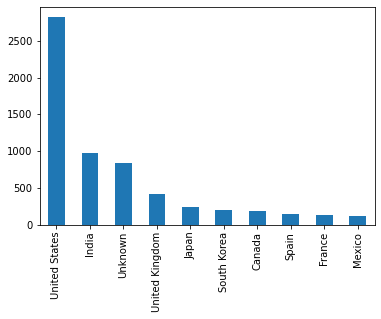

In [165]:
# Plot number of movies Vs Tv shows
sns.countplot(x='type', data=df)
plt.show()
# Plot Top 10 Countries with most Netflix titles
df['country'].value_counts().head(10).plot(kind='bar')
plt.show()

In [166]:
# Convert columns to string type
df.loc[:, 'genre'] = df['genre'].astype(str)
df.loc[:, 'duration'] = df['duration'].astype(str)
# Split genres into list
df.loc[:, 'genre'] = df['genre'].str.split(',')
# Remove 'Min' text from duration 
df.loc[:, 'duration'] = df['duration'].str.replace(' min', '', regex=False)
df.tail()

,type,title,director,country,release_year,rating,duration,genre
8802,Movie,zodiac,David Fincher,United States,2007,R,158,"[Cult Movies, Dramas, Thrillers]"
8803,TV Show,zombie dumb,Unknown,Unknown,2018,TV-Y7,2 Seasons,"[Kids' TV, Korean TV Shows, TV Comedies]"
8804,Movie,zombieland,Ruben Fleischer,United States,2009,R,88,"[Comedies, Horror Movies]"
8805,Movie,zoom,Peter Hewitt,United States,2006,PG,88,"[Children & Family Movies, Comedies]"
8806,Movie,zubaan,Mozez Singh,India,2015,TV-14,111,"[Dramas, International Movies, Music & Music..."


In [167]:
# Convert categorical values into numerical values
le = LabelEncoder()
# Encode 'type'
df['type_encoded'] = le.fit_transform(df['type'])
# Encode 'rating'
df['rating_encoded'] = le.fit_transform(df['rating'])
df.head()

,type,title,director,country,release_year,rating,duration,genre,type_encoded,rating_encoded
0,Movie,dick johnson is dead,Kirsten Johnson,United States,2020,PG-13,90,[Documentaries],0,8
1,TV Show,blood & water,Unknown,South Africa,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Myste...",1,12
2,TV Show,ganglands,Julien Leclercq,Unknown,2021,TV-MA,1 Season,"[Crime TV Shows, International TV Shows, TV ...",1,12
3,TV Show,jailbirds new orleans,Unknown,Unknown,2021,TV-MA,1 Season,"[Docuseries, Reality TV]",1,12
4,TV Show,kota factory,Unknown,India,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, ...",1,12


In [168]:
# Extract numeric part from duration column
df['duration_num'] = df['duration'].str.extract('(\d+)')
# Convert extracted value to float
df['duration_num'] = df['duration_num'].astype(float)
df.head()

,type,title,director,country,release_year,rating,duration,genre,type_encoded,rating_encoded,duration_num
0,Movie,dick johnson is dead,Kirsten Johnson,United States,2020,PG-13,90,[Documentaries],0,8,90.0
1,TV Show,blood & water,Unknown,South Africa,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Myste...",1,12,2.0
2,TV Show,ganglands,Julien Leclercq,Unknown,2021,TV-MA,1 Season,"[Crime TV Shows, International TV Shows, TV ...",1,12,1.0
3,TV Show,jailbirds new orleans,Unknown,Unknown,2021,TV-MA,1 Season,"[Docuseries, Reality TV]",1,12,1.0
4,TV Show,kota factory,Unknown,India,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, ...",1,12,2.0


In [169]:
# Select features for clustering
features = df[['release_year','duration_num','type_encoded','rating_encoded']]
# Remove rows with missing values
features = features.dropna()

In [170]:
# Standardize the feature values
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

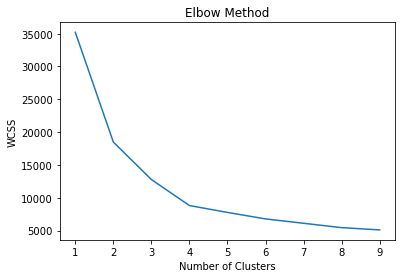

In [171]:
# List two store WCSS values
wcss = []
# Run KMeans for cluster from 1-9
for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)
# Plot elbow graphs
plt.plot(range(1,10), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [172]:
# Apply KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
# Predict cluster labels
clusters = kmeans.fit_predict(scaled_features)
# Add cluster columns
features['cluster'] = clusters

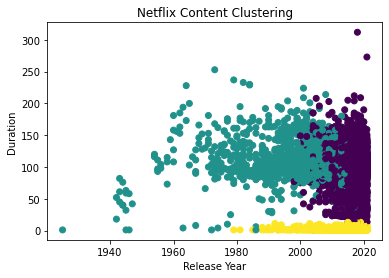

In [173]:
# Scatter plot of cluster
plt.scatter(features['release_year'], features['duration_num'], c=features['cluster'])
plt.xlabel("Release Year")
plt.ylabel("Duration")
plt.title("Netflix Content Clustering")
plt.show()

In [174]:
# Import FileLink from IPython.display
# This is used to create a clickable download link in Jupyter Notebook
from IPython.display import FileLink

# Convert the cleaned DataFrame into an Excel file
df.to_excel("cleaned_netflix_dataset.xlsx", index=False)

# Create a clickable download link for the Excel file in the Jupyter Notebook output
FileLink("cleaned_netflix_dataset.xlsx")

/home/fb35774f-8612-4fbe-93a9-1f9d52255ff1/cleaned_netflix_dataset.xlsx